# SEC-MALS Plotting Notebook

Creates publication-quality SEC-MALS chromatograms from ASTRA exports.

**Input format:** Tab-separated ASTRA export with European number format (comma as decimal separator, period as thousands separator).

**Expected column layout:**
```
Columns 0–7 : BSA standard  →  (vol, UV), (vol, dRI), (vol, UV_dup), (vol, LS_raw)
Columns 8–15: Sample         →  (vol, UV), (vol, dRI), (vol, UV_dup), (vol, Mw_Da)
```
The Mw column contains data only inside the integration window set in ASTRA.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'pdf.fonttype': 42,   # editable text in Illustrator
    'svg.fonttype': 'none',
})

## 1. Load data

In [2]:
# ── Configure file path here ───────────────────────────────────────────────────
DATA_FILE = Path('/Users/ajakobi/Downloads/20251217_dynA.txt')

# Labels that will appear in plots and legend
SAMPLE_LABEL = 'DynA'
BSA_LABEL    = 'BSA'


# ── Parser ────────────────────────────────────────────────────────────────────
def _eu(s: str) -> float:
    """Parse a European-format number ('1.234,56' → 1234.56)."""
    s = str(s).strip()
    if s in ('', 'nan', 'NaN', 'None'):
        return np.nan
    s = s.replace('.', '')   # strip thousands sep
    s = s.replace(',', '.')  # replace decimal comma
    try:
        return float(s)
    except ValueError:
        return np.nan


def load_astra_export(filepath: Path) -> pd.DataFrame:
    """
    Load a two-sample ASTRA SEC-MALS export file.

    File has 16 tab-separated columns, no row-number prefix.

    Column layout (pairs of volume, signal):
      0–1  : BSA UV
      2–3  : BSA dRI
      4–5  : BSA UV duplicate (same as 0–1)
      6–7  : BSA raw LS (only filled inside the integration window)
      8–9  : Sample UV
      10–11: Sample dRI
      12–13: Sample UV duplicate (same as 8–9)
      14–15: Sample Mw in Da (only filled inside the integration window)
    """
    col_names = [
        'bsa_uv_vol',  'bsa_uv',
        'bsa_ri_vol',  'bsa_ri',
        '_bsa_uv2v',   '_bsa_uv2',
        'bsa_ls_vol',  'bsa_ls',
        'dyna_uv_vol', 'dyna_uv',
        'dyna_ri_vol', 'dyna_ri',
        '_dyna_uv2v',  '_dyna_uv2',
        'dyna_mw_vol', 'dyna_mw_da',
    ]

    rows = []
    with open(filepath, encoding='utf-8') as fh:
        for i, line in enumerate(fh):
            if i == 0:      # header row — skip
                continue
            parts = line.rstrip('\n').split('\t')
            # 16 data columns, no row-number prefix
            vals = [_eu(p) for p in parts[0:16]]
            while len(vals) < 16:
                vals.append(np.nan)
            rows.append(vals)

    return pd.DataFrame(rows, columns=col_names)


df = load_astra_export(DATA_FILE)
print(f'Loaded {len(df):,} data rows from {DATA_FILE.name}')

# ── Quick summary ──────────────────────────────────────────────────────────────
def _rng(col):
    s = df[col].dropna()
    return f'{s.min():.3f} – {s.max():.3f}  (n={len(s):,})'

print(f"\nBSA  UV   volume : {_rng('bsa_uv_vol')} mL")
print(f"BSA  UV   signal : {_rng('bsa_uv')}")
print(f"BSA  dRI  volume : {_rng('bsa_ri_vol')} mL")
print(f"BSA  dRI  signal : {_rng('bsa_ri')}")
print()
print(f"DynA UV   volume : {_rng('dyna_uv_vol')} mL")
print(f"DynA UV   signal : {_rng('dyna_uv')}")
print(f"DynA dRI  volume : {_rng('dyna_ri_vol')} mL")
print(f"DynA dRI  signal : {_rng('dyna_ri')}")
print()
mw_data = df.dropna(subset=['dyna_mw_vol', 'dyna_mw_da'])
print(f"DynA Mw   volume : {mw_data['dyna_mw_vol'].min():.2f} – {mw_data['dyna_mw_vol'].max():.2f} mL  (n={len(mw_data)})")
print(f"DynA Mw   range  : {mw_data['dyna_mw_da'].min()/1e3:.1f} – {mw_data['dyna_mw_da'].max()/1e3:.1f} kDa")
print(f"DynA Mw   median : {mw_data['dyna_mw_da'].median()/1e3:.1f} kDa")

Loaded 6,471 data rows from 20251217_dynA.txt

BSA  UV   volume : 10.001 – 36.491  (n=6,470) mL
BSA  UV   signal : -0.504 – 1.000  (n=6,470)
BSA  dRI  volume : 9.942 – 36.432  (n=6,470) mL
BSA  dRI  signal : -0.004 – 1.000  (n=6,470)

DynA UV   volume : 0.002 – 26.492  (n=6,470) mL
DynA UV   signal : -0.135 – 1.000  (n=6,470)
DynA dRI  volume : -0.057 – 26.433  (n=6,470) mL
DynA dRI  signal : -0.001 – 1.000  (n=6,470)

DynA Mw   volume : 12.95 – 13.63 mL  (n=69)
DynA Mw   range  : 121.5 – 152.8 kDa
DynA Mw   median : 133.0 kDa


## 2. Quick overview — all signals

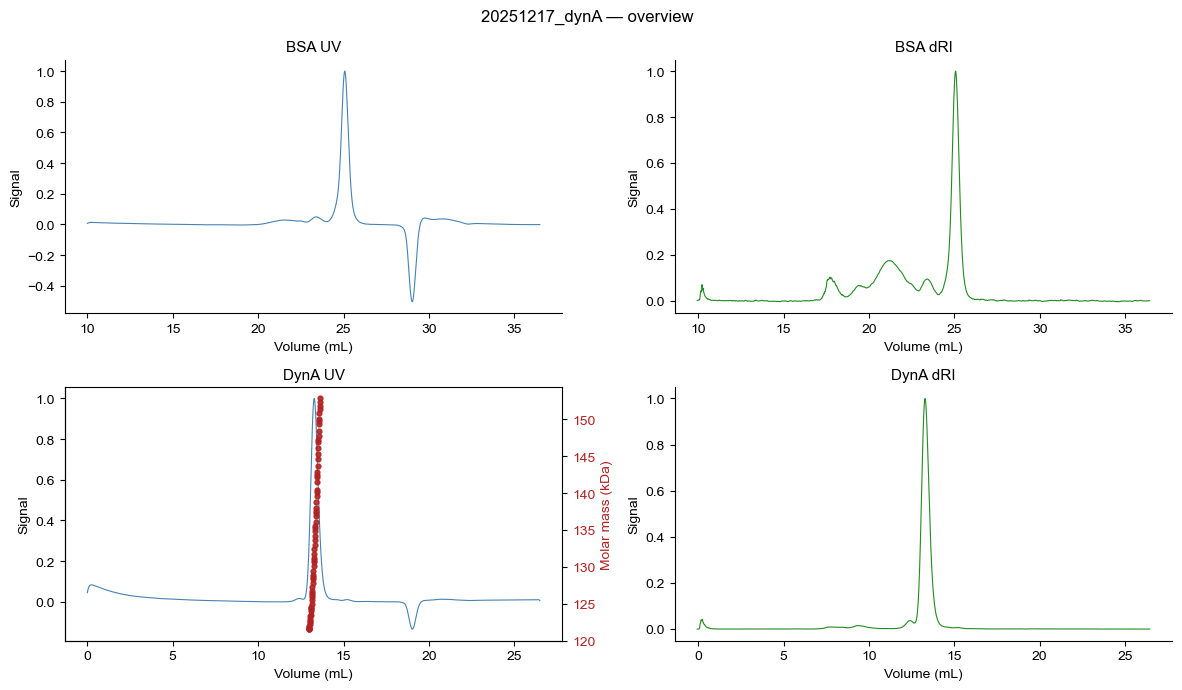

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

pairs = [
    ('bsa_uv_vol',  'bsa_uv',      'BSA UV',        axes[0, 0], 'steelblue'),
    ('bsa_ri_vol',  'bsa_ri',      'BSA dRI',        axes[0, 1], 'forestgreen'),
    ('dyna_uv_vol', 'dyna_uv',     'DynA UV',        axes[1, 0], 'steelblue'),
    ('dyna_ri_vol', 'dyna_ri',     'DynA dRI',       axes[1, 1], 'forestgreen'),
]

for vcol, scol, title, ax, color in pairs:
    sub = df[[vcol, scol]].dropna()
    ax.plot(sub[vcol], sub[scol], color=color, lw=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Volume (mL)')
    ax.set_ylabel('Signal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Add Mw on DynA UV panel
ax_dyna = axes[1, 0]
ax_mw   = ax_dyna.twinx()
ax_mw.scatter(mw_data['dyna_mw_vol'], mw_data['dyna_mw_da'] / 1e3,
              color='firebrick', s=12, zorder=5, alpha=0.9)
ax_mw.set_ylabel('Molar mass (kDa)', color='firebrick')
ax_mw.tick_params(axis='y', labelcolor='firebrick')

fig.suptitle(f'{DATA_FILE.stem} — overview', fontsize=12)
fig.tight_layout()
plt.show()

## 3. Publication-quality SEC-MALS plot

/var/folders/g0/l5g1vzlx1836242dlnzx6gq9w2cnw7/T/ipykernel_82967/391167284.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


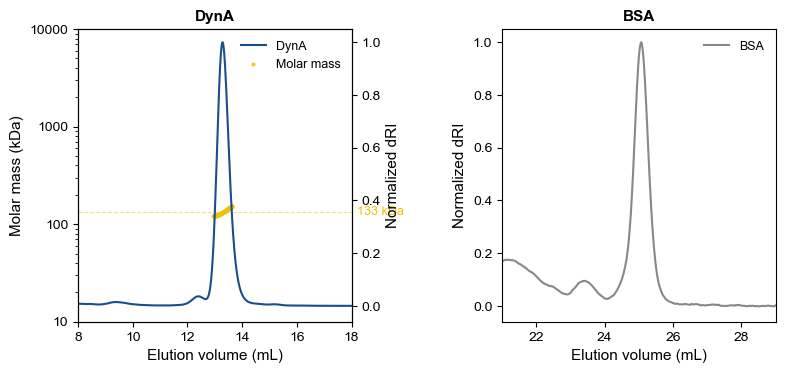

In [4]:
# ── Parameters ─────────────────────────────────────────────────────────────────
# DynA peak: ~13.3 mL   BSA (reference) peak: ~25.1 mL
DYNA_VOL_RANGE = (8.0, 18.0)    # mL
BSA_VOL_RANGE  = (21.0, 29.0)   # mL  (set to None to show only DynA)

# Molar mass y-axis (left), logarithmic scale — must not include 0
MW_YLIM = (10, 10000)   # kDa

# Only show Mw dots where dRI ≥ this fraction of peak
MW_RI_THRESHOLD = 0.10

# Colors
C_MW   = "#f0c106"   # red  — molar mass (left axis)
C_DYNA = '#1a4f8a'   # blue — dRI trace  (right axis)
C_BSA  = '#888888'   # gray — BSA reference


# ── Helper ────────────────────────────────────────────────────────────────────
def _slice(df, vcol, scol, vmin, vmax):
    m = (df[vcol] >= vmin) & (df[vcol] <= vmax)
    return df.loc[m, vcol].values, df.loc[m, scol].values


# ── Layout ────────────────────────────────────────────────────────────────────
show_bsa = BSA_VOL_RANGE is not None
if show_bsa:
    fig, (ax_d, ax_b) = plt.subplots(1, 2, figsize=(9, 3.8),
                                      gridspec_kw={'wspace': 0.55})
else:
    fig, ax_d = plt.subplots(1, 1, figsize=(4.5, 3.8))


# ── DynA panel: left = Mw (log), right = dRI ──────────────────────────────────
ax_ri = ax_d.twinx()   # right axis — dRI

# Right axis: normalized dRI
vd, sd = _slice(df, 'dyna_ri_vol', 'dyna_ri', *DYNA_VOL_RANGE)
sd_norm = sd / sd.max() if sd.max() > 0 else sd
ax_ri.plot(vd, sd_norm, color=C_DYNA, lw=1.5, label=SAMPLE_LABEL)
ax_ri.set_ylim(-0.06, 1.05)
ax_ri.set_ylabel('Normalized dRI', color='#000000', fontsize=11)
ax_ri.tick_params(axis='y', labelcolor='#000000')

# Left axis: molar mass scatter (log scale)
mw_sub = mw_data[
    (mw_data['dyna_mw_vol'] >= DYNA_VOL_RANGE[0]) &
    (mw_data['dyna_mw_vol'] <= DYNA_VOL_RANGE[1])
].copy()
if len(mw_sub) > 0 and len(vd) > 0:
    ri_at_mw = np.interp(mw_sub['dyna_mw_vol'], vd, sd_norm)
    mw_sub = mw_sub[ri_at_mw >= MW_RI_THRESHOLD]

mw_kda = mw_sub['dyna_mw_da'].values / 1e3
vol_mw = mw_sub['dyna_mw_vol'].values

ax_d.scatter(vol_mw, mw_kda, color=C_MW, s=4, zorder=5, alpha=0.8, label='Molar mass')

if len(mw_kda) > 0:
    # Group Mw data into contiguous integration windows separated by gaps > 0.5 mL
    mw_df  = mw_sub.sort_values('dyna_mw_vol').copy()
    seg_id = (mw_df['dyna_mw_vol'].diff() > 0.5).cumsum()

    seg_info = []                    # [(vol_right_edge, median_kDa), ...]
    for _, seg in mw_df.groupby(seg_id):
        mw_med  = float(np.median(seg['dyna_mw_da'].values / 1e3))
        vol_end = float(seg['dyna_mw_vol'].max())
        seg_info.append((vol_end, mw_med))
        ax_d.axhline(mw_med, color=C_MW, lw=0.8, ls='--', alpha=0.5)

    # De-overlap annotation y positions in log space
    order      = sorted(range(len(seg_info)), key=lambda i: seg_info[i][1])
    label_ys   = [seg_info[i][1] for i in order]
    min_log_gap = 0.15          # ≈ 14 pt at typical figure size; adjust if needed
    changed = True
    while changed:
        changed = False
        for k in range(1, len(label_ys)):
            if np.log10(label_ys[k]) - np.log10(label_ys[k - 1]) < min_log_gap:
                mid           = 0.5 * (np.log10(label_ys[k]) + np.log10(label_ys[k - 1]))
                label_ys[k - 1] = 10 ** (mid - min_log_gap / 2)
                label_ys[k]     = 10 ** (mid + min_log_gap / 2)
                changed       = True

    # Place labels at the right edge using a blended (axes-x, data-y) transform
    from matplotlib.transforms import blended_transform_factory as _btf
    trans  = _btf(ax_d.transAxes, ax_d.transData)
    x_edge = DYNA_VOL_RANGE[1]
    for rank, orig_i in enumerate(order):
        _, mw_med = seg_info[orig_i]
        label_y   = label_ys[rank]
        ax_d.text(1.02, label_y, f'{mw_med:.0f} kDa',
                  transform=trans, color=C_MW, fontsize=9,
                  va='center', ha='left', clip_on=False)
        # Thin connector when the label had to be nudged from the dashed line
        if abs(np.log10(label_y / mw_med)) > 0.02:
            ax_d.plot([x_edge, x_edge], [mw_med, label_y],
                      color=C_MW, lw=0.4, ls=':', clip_on=False, zorder=4)

ax_d.set_xlim(DYNA_VOL_RANGE)
ax_d.set_ylim(*MW_YLIM)
ax_d.set_yscale('log')
ax_d.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
ax_d.set_xlabel('Elution volume (mL)', fontsize=11)
ax_d.set_ylabel('Molar mass (kDa)', color='#000000', fontsize=11)
ax_d.tick_params(axis='y', labelcolor='#000000')
ax_d.set_title(SAMPLE_LABEL, fontsize=11, fontweight='bold')

# Full box border
for ax in (ax_d, ax_ri):
    for spine in ax.spines.values():
        spine.set_visible(True)

# Legend
h1, l1 = ax_ri.get_legend_handles_labels()
h2, l2 = ax_d.get_legend_handles_labels()
ax_d.legend(h1 + h2, l1 + l2, loc='upper right', frameon=False, fontsize=9)


# ── BSA panel (reference) ─────────────────────────────────────────────────────
if show_bsa:
    vb, sb = _slice(df, 'bsa_ri_vol', 'bsa_ri', *BSA_VOL_RANGE)
    sb_norm = sb / sb.max() if (len(sb) > 0 and sb.max() > 0) else sb

    ax_b.plot(vb, sb_norm, color=C_BSA, lw=1.5, label=BSA_LABEL)
    ax_b.set_xlim(BSA_VOL_RANGE)
    ax_b.set_ylim(-0.06, 1.05)
    ax_b.set_xlabel('Elution volume (mL)', fontsize=11)
    ax_b.set_ylabel('Normalized dRI', fontsize=11)
    ax_b.set_title(BSA_LABEL, fontsize=11, fontweight='bold')
    for spine in ax_b.spines.values():
        spine.set_visible(True)
    ax_b.legend(loc='upper right', frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

## 5. Save figure

## 4. Protein conjugate — multi-component mass plot

For samples where ASTRA decomposes the total molar mass into contributions from two chemically distinct components (protein + DNA, protein + detergent micelle, protein + nanodisc lipid, …). The export has **12 columns** (no BSA reference):

```
Cols 0–1  : UV chromatogram  (full run)
Cols 2–3  : dRI chromatogram (full run)
Cols 4–5  : second detector  (full run)
Cols 6–7  : Total molar mass (Da)      — peak region only
Cols 8–9  : Component 1 mass (Da)      — peak region only
Cols 10–11: Component 2 mass (Da)      — peak region only
```

Numbers use the **standard English decimal format** (period as decimal separator), not the European comma-format used in the two-sample files.

In [ ]:
# ── Configure file path here ───────────────────────────────────────────────────
DATA_FILE_CONJ = Path('/Users/ajakobi/Downloads/Protein conjugate RampCrispr1.txt')

# Sample label (title) and component names (legend + MW annotations)
SAMPLE_LABEL_CONJ = 'RampCrispr1'
PROTEIN_LABEL     = 'Protein'
COMPONENT2_LABEL  = 'DNA'

# Volume range to display (mL)
CONJ_VOL_RANGE = (8.0, 13.0)

# Molar mass y-axis range (kDa, log scale)
CONJ_MW_YLIM = (10, 10000)

# Only annotate Mw where normalized dRI >= this fraction of peak
CONJ_MW_RI_THRESHOLD = 0.10

# Colors
C_TOTAL    = '#e8b004'   # gold  — total complex
C_PROTEIN  = '#1a4f8a'   # blue  — protein contribution
C_COMP2    = '#c0392b'   # red   — component 2 (DNA / detergent / …)
C_CONJ_SIG = '#555555'   # gray  — dRI chromatogram


# ── Loader ─────────────────────────────────────────────────────────────────────
def load_conjugate_export(filepath: Path) -> pd.DataFrame:
    """
    12-column ASTRA protein-conjugate export (English number format).
    Each pair is (volume_mL, signal); columns have different lengths
    because the MW series is non-empty only inside the ASTRA integration window.
    """
    col_names = [
        'uv_vol',       'uv',
        'ri_vol',       'ri',
        'sig2_vol',     'sig2',
        'mw_total_vol', 'mw_total_da',
        'mw_prot_vol',  'mw_prot_da',
        'mw_comp2_vol', 'mw_comp2_da',
    ]
    rows = []
    with open(filepath, encoding='utf-8') as fh:
        for i, line in enumerate(fh):
            if i == 0:
                continue
            parts = line.rstrip('\n').split('\t')
            vals = []
            for p in parts[:12]:
                p = p.strip()
                try:
                    vals.append(float(p))
                except (ValueError, TypeError):
                    vals.append(np.nan)
            while len(vals) < 12:
                vals.append(np.nan)
            rows.append(vals)
    return pd.DataFrame(rows, columns=col_names)


df_conj = load_conjugate_export(DATA_FILE_CONJ)
print(f'Loaded {len(df_conj):,} rows from {DATA_FILE_CONJ.name}')

for vcol, mcol, lbl in [
    ('mw_total_vol', 'mw_total_da', 'Total'),
    ('mw_prot_vol',  'mw_prot_da',  PROTEIN_LABEL),
    ('mw_comp2_vol', 'mw_comp2_da', COMPONENT2_LABEL),
]:
    sub = df_conj.dropna(subset=[vcol, mcol])
    if len(sub):
        print(f'  {lbl:<12}: {sub[mcol].median()/1e3:.1f} kDa  '
              f'(range {sub[mcol].min()/1e3:.1f}–{sub[mcol].max()/1e3:.1f} kDa, n={len(sub)})')
    else:
        print(f'  {lbl:<12}: no data')

In [ ]:
def _slice_conj(df, vcol, scol, vmin, vmax):
    m = df[[vcol, scol]].notna().all(axis=1) & (df[vcol] >= vmin) & (df[vcol] <= vmax)
    return df.loc[m, vcol].values, df.loc[m, scol].values


# ── Figure ─────────────────────────────────────────────────────────────────────
fig, ax_mw = plt.subplots(1, 1, figsize=(5, 4))
ax_sig = ax_mw.twinx()

# dRI chromatogram (right axis, normalized)
vs, ss = _slice_conj(df_conj, 'ri_vol', 'ri', *CONJ_VOL_RANGE)
ss_norm = ss / ss.max() if ss.max() > 0 else ss
ax_sig.plot(vs, ss_norm, color=C_CONJ_SIG, lw=1.5, label=SAMPLE_LABEL_CONJ)
ax_sig.set_ylim(-0.06, 1.05)
ax_sig.set_ylabel('Normalized dRI', fontsize=11)

# Three Mw scatter series
mw_series = [
    ('mw_total_vol', 'mw_total_da', C_TOTAL,   'Total'),
    ('mw_prot_vol',  'mw_prot_da',  C_PROTEIN, PROTEIN_LABEL),
    ('mw_comp2_vol', 'mw_comp2_da', C_COMP2,   COMPONENT2_LABEL),
]

entries = []   # (median_kDa, color, label_text) — for annotation
for vcol, mcol, color, lbl in mw_series:
    v, m = _slice_conj(df_conj, vcol, mcol, *CONJ_VOL_RANGE)
    if len(v) == 0:
        continue
    ri_at_mw = np.interp(v, vs, ss_norm, left=0.0, right=0.0)
    mask = ri_at_mw >= CONJ_MW_RI_THRESHOLD
    vf, kda_f = v[mask], m[mask] / 1e3
    ax_mw.scatter(vf, kda_f, color=color, s=4, zorder=5, alpha=0.9, label=lbl)
    if len(kda_f):
        med = float(np.median(kda_f))
        ax_mw.axhline(med, color=color, lw=0.8, ls='--', alpha=0.5)
        entries.append((med, color, lbl))

# ── Median labels — inside axes, white bbox, log-space de-overlap ──────────────
entries.sort(key=lambda e: e[0])
label_ys = [e[0] for e in entries]

min_log_gap = 0.18
changed = True
while changed:
    changed = False
    for k in range(1, len(label_ys)):
        if np.log10(label_ys[k]) - np.log10(label_ys[k - 1]) < min_log_gap:
            mid = 0.5 * (np.log10(label_ys[k]) + np.log10(label_ys[k - 1]))
            label_ys[k - 1] = 10 ** (mid - min_log_gap / 2)
            label_ys[k]     = 10 ** (mid + min_log_gap / 2)
            changed = True

from matplotlib.transforms import blended_transform_factory as _btf
trans = _btf(ax_mw.transAxes, ax_mw.transData)

for (med, color, lbl), label_y in zip(entries, label_ys):
    ax_mw.text(0.97, label_y, f'{med:.0f} kDa ({lbl})',
               transform=trans, color=color, fontsize=8,
               va='center', ha='right',
               bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.85))

# ── Axes formatting ────────────────────────────────────────────────────────────
ax_mw.set_xlim(CONJ_VOL_RANGE)
ax_mw.set_ylim(*CONJ_MW_YLIM)
ax_mw.set_yscale('log')
ax_mw.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
ax_mw.set_xlabel('Elution volume (mL)', fontsize=11)
ax_mw.set_ylabel('Molar mass (kDa)', fontsize=11)
ax_mw.set_title(SAMPLE_LABEL_CONJ, fontsize=11, fontweight='bold')

for ax in (ax_mw, ax_sig):
    for spine in ax.spines.values():
        spine.set_visible(True)

h1, l1 = ax_sig.get_legend_handles_labels()
h2, l2 = ax_mw.get_legend_handles_labels()
ax_mw.legend(h1 + h2, l1 + l2, loc='upper left', frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

In [5]:
# ── Run cells 3–4 first, then save the figure you want ────────────────────────
OUTPUT_STEM = DATA_FILE.stem   # e.g. '20251217_dynA'

# Save the last figure
for ext in ('pdf', 'png'):
    out = DATA_FILE.parent / f'{OUTPUT_STEM}_sec_mals.{ext}'
    fig.savefig(out, dpi=300, bbox_inches='tight')
    print(f'Saved → {out}')

Saved → /Users/ajakobi/Downloads/20251217_dynA_sec_mals.pdf
Saved → /Users/ajakobi/Downloads/20251217_dynA_sec_mals.png
